# Tutorial 2

Pada tutorial sebelumnya, kita telah membahas tahapan awal dalam membangun sebuah sistem *information retrieval*, khususnya proses *pre-processing* sebelum dokumen di-*index*. Tahapan ini mencakup berbagai teknik dasar seperti *tokenization*, *stopword removal*, dan normalisasi teks. Tujuan dari proses tersebut adalah untuk mengubah teks mentah menjadi representasi yang lebih terstruktur sehingga dapat diproses secara efisien oleh sistem pencarian.

Setelah dokumen diproses dan direpresentasikan dalam bentuk token atau term, langkah berikutnya adalah membangun mekanisme untuk menemukan dokumen yang relevan terhadap sebuah *query*. Pada bagian ini kita mulai masuk ke pendekatan *retrieval* yang digunakan untuk melakukan pencarian dan pemeringkatan dokumen dalam koleksi yang telah di-*index*.

## Sparse Ranked Retrieval

Sparse retrieval merupakan pendekatan retrieval yang memanfaatkan *bag of words* atau frekuensi kemunculan kata pada seluruh dokumen yang dimiliki. Pendekatan ini masih digunakan sebagai dalam *search engine* karena efisiensinya yang tinggi dan kemampuannya dalam melakukan *exact match query*.

Karena pendekatan ini tidak mempertimbangkan urutan kemunculan kata dan semantik, diperlukan sebuah fungsi untuk melakukan *scoring* untuk melakukan *ranking* pada dokumen yang kita miliki untuk sebuah *query*

### Inverted Index

Pada pendekatan *sparse retrieval* berbasis *bag of words*, kita perlu mengetahui seberapa sering setiap kata muncul di setiap dokumen. Jika setiap kali ada *query* baru *search engine* harus memeriksa seluruh dokumen dari awal sampai akhir, proses pencarian tentu akan menjadi sangat lambat. Oleh karena itu, digunakan sebuah struktur data yang disebut *inverted index*.

Secara sederhana, *inverted index* memetakan setiap *term* unik ke daftar dokumen yang mengandung *term* tersebut. Selain itu, struktur ini juga menyimpan informasi tambahan seperti nilai *term frequency* $TF(t, d)$ serta metadata lain (misalnya panjang dokumen) yang nantinya digunakan dalam proses *scoring* dan pemeringkatan hasil pencarian.

Keywords:

1. *document*: satu unit teks yang berdiri sendiri (misalnya artikel, halaman web, atau paragraf).
2. *term*: kata tunggal atau token hasil proses tokenisasi.
3. *postings*: daftar *document ID* yang menunjukkan dokumen mana saja yang mengandung suatu *term*.


In [ ]:
import math
from collections import defaultdict, Counter

corpus = {
    1: "anjing coklat yang cepat melompat",
    2: "rubah coklat yang cepat berenang",
    3: "anjing cepat"
}

def build_index_with_tf(corpus):
    index = defaultdict(dict)
    doc_lengths = {}

    for doc_id, text in corpus.items():
        terms = text.split()
        doc_lengths[doc_id] = len(terms)
        term_counts = Counter(terms)

        for term, count in term_counts.items():
            index[term][doc_id] = count

    return index, doc_lengths

index, doc_lengths = build_index_with_tf(corpus)
N = len(corpus) # Total dokumen
avgdl = sum(doc_lengths.values()) / N

print("Postings untuk kata 'cepat':", index['cepat'])
print("Postings untuk kata 'coklat':", index['coklat'])

Postings untuk kata 'cepat': {1: 1, 2: 1, 3: 1}
Postings untuk kata 'coklat': {1: 1, 2: 1}


### Weighting/Scoring for Ranked Sparse Retrieval Systems

### tf-idf

Jika kita hanya mengandalkan *term frequency* (TF) untuk memberi skor pada dokumen, hasilnya sering kali belum benar-benar mencerminkan relevansi dokumen terhadap *query*. Hal ini terjadi karena kata-kata yang sangat umum seperti *stop words* dapat muncul berkali-kali dalam sebuah dokumen, sehingga dokumen tersebut bisa mendapatkan skor tinggi meskipun sebenarnya tidak terlalu informatif.

Untuk mengatasi masalah tersebut, digunakan konsep *inverse document frequency* (IDF). Ide dasarnya sederhana. Semakin jarang sebuah *term* muncul di seluruh koleksi dokumen, semakin besar nilai informasinya. Dengan kata lain, *term* yang jarang muncul biasanya lebih membantu membedakan dokumen yang benar-benar relevan dari yang tidak.

Nilai IDF dapat dihitung menggunakan persamaan berikut:

$$
IDF = \log_{10} \left( \frac{N}{DF(t)} \right)
$$

Dimana:

* $N$: jumlah total dokumen dalam koleksi.
* $DF(t)$: jumlah dokumen yang mengandung *term* $t$.

Dengan menggabungkan TF dan IDF, kita mendapatkan bobot yang lebih seimbang untuk menilai relevansi dokumen terhadap *query*. Skor tf-idf untuk sebuah dokumen $D$ terhadap *query* $Q$ dapat dihitung dengan persamaan berikut:

$$
score(Q, D) = \sum_{t \in Q \cap D} \left(1+\log_{10}(TF(t, D))\right) \times \log_{10} \left(\frac{N}{DF(t)}\right)
$$

Melalui kombinasi ini, *term* yang sering muncul dalam dokumen tetapi jarang muncul di *collection* secara keseluruhan akan mendapatkan bobot yang lebih tinggi, sehingga membantu sistem pencarian menemukan dokumen yang lebih relevan.


In [ ]:
def score_tfidf(query, index, N):
    query_terms = query.split()
    scores = defaultdict(float)

    for term in query_terms:
        if term in index:
            df = len(index[term])
            idf = math.log(N / df) # Diperlukan log untuk sublinear scaling

            for doc_id, tf in index[term].items():
                scores[doc_id] += (1+math.log(tf)) * idf  # Varian tfidf

    return dict(scores)

### BM25

Berbeda dengan TF-IDF yang menggunakan $1 + \log_{10} TF(t, D)$, model tersebut mengasumsikan bahwa setiap penambahan frekuensi term $t$ pada dokumen $D$ akan terus meningkatkan skor relevansi secara sub-linear tanpa batas. BM25 mengatasi hal ini dengan mendefinisikan *term eliteness* memberikan bobot lebih pada *term* yang muncul beberapa kali dengan mekanisme saturasi (terlalu banyak kemunculan *term* tidak menambah signifikansi). Mekanisme scoring ini dimodelkan dengan persamaan berikut:
$$\frac{TF(t, D) \cdot (k_1 + 1)}{TF(t, D) + k_1}$$
Dimana:
- k1 merupakan parameter yang mengatur kecepatan saturasi



Selain itu untuk menghilangkan bias panjang dokumen pada mekanisme scoring, BM25 juga memiliki *length normalization* menggunakan formula berikut:
$$B = (1 - b) + b \cdot \frac{|D|}{avgdl}$$
Dimana:
- $|D|$: Panjang dokumen (total kata dalam dokumen $D$).
- $avgdl$: Rata-rata panjang seluruh dokumen dalam koleksi.
- $b$: Parameter yang mengatur besarnya normalisasi ($0 \leq b \leq 1$)
  
Dengan menggabungkan *eliteness*,*length normalization*, dan IDF, bobot sebuah dokumen $D$ pada *query* $Q$ dapat dihitung fungsi skor BM25 berikut:

$$score(Q, D) = \sum_{t \in Q \cap D} \underbrace{\log_{10} \left( \frac{N}{DF(t)} \right)}_{\text{IDF}} \cdot \underbrace{\frac{TF(t, D) \cdot (k_1 + 1)}{TF(t, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{avgdl}\right)}}_{\text{TF Saturation + Length Norm}}$$


In [ ]:
def score_bm25(query, index, N, doc_lengths, avgdl, k1=1.5, b=0.75):
    query_terms = query.split()
    scores = defaultdict(float)

    for term in query_terms:
        if term in index:
            df_t = len(index[term])

            idf = math.log(N / df_t)

            for doc_id, tf_t in index[term].items():
                dl = doc_lengths[doc_id]

                numerator = (k1 + 1) * tf_t
                denominator = k1 * ((1 - b) + b * (dl / avgdl)) + tf_t

                scores[doc_id] += idf * (numerator / denominator)

    return dict(scores)

### Query Likelihood Model (QLM)

Berbeda dengan TF-IDF atau BM25 yang menggunakan pendekatan heuristik, *Query Likelihood Model* (QLM) berasal dari pendekatan probabilistik dalam *language model*. Dalam praktiknya, QLM biasanya menggunakan *unigram language model* yang mengasumsikan bahwa setiap kata dalam *query* muncul secara independen satu sama lain.

Dengan asumsi tersebut, skor sebuah dokumen dihitung dari probabilitas bahwa dokumen tersebut dapat menghasilkan *query*. Secara matematis, skor ini diperoleh dengan mengalikan probabilitas setiap term $q$ dalam *query* berdasarkan distribusi probabilitas dokumen $\theta_D$.

$$
score(Q,D) = P(Q|\theta_D) = \prod_{i=1}^{n} P(q_i|\theta_D)
$$

Untuk memperkirakan probabilitas kemunculan suatu term dalam dokumen, kita dapat menggunakan frekuensi kemunculan term $TF(t, D)$ yang dibagi dengan jumlah total kata dalam dokumen $N_D$.

$$
P(t|\theta_D) = \frac{TF(t, D)}{N_D}
$$

#### Apa yang terjadi jika ada satu term query yang tidak ditemukan di dokumen?

Jika sebuah term dari *query* tidak muncul di dokumen, maka probabilitasnya akan menjadi nol dan seluruh skor dokumen juga menjadi nol. Untuk menghindari hal ini, biasanya digunakan teknik *smoothing*.

Seperti yang sudah diajarkan, pendekatan paling mudah adalah *laplace smoothing* dimana $P(t|D)$ dapat dihitung sebagai berikut

$$
P(t|D) = \frac{(1+TF(t, D))}{(N_D+|V|}
$$

Dimana:
- |V| merupakan total vocab yang dimiliki


Salah satu pendekatannya adalah *linear interpolation*. Ide dasarnya adalah menggabungkan probabilitas dari *language model* dokumen $\theta_D$ dengan probabilitas dari seluruh koleksi dokumen atau korpus $\theta_C$. Dengan cara ini, dokumen yang tidak memiliki sebuah term tetap mendapatkan probabilitas kecil yang berasal dari distribusi korpus.

$$
P(t|D) = \alpha P(t|\theta_D) + (1 - \alpha) P(t|\theta_C)
$$

Dimana:

* $\alpha$ adalah parameter bobot dengan nilai antara 0 dan 1
* $P(t|\theta_D)$ adalah probabilitas term berdasarkan frekuensi dalam dokumen $D$
* $P(t|\theta_C)$ adalah probabilitas term berdasarkan frekuensi dalam seluruh korpus

Selain *linear interpolation*, terdapat juga metode *smoothing* lain yang cukup sering digunakan, misalnya *Dirichlet smoothing*.

Additional material:

- [https://ils.unc.edu/~jarguell/inls509_002/lectures/07-QueryLikelihoodModel.pdf](https://ils.unc.edu/~jarguell/inls509_002/lectures/07-QueryLikelihoodModel.pdf)


In [ ]:
def score_qlm(query, index, doc_lengths, alpha=0.8, smoothing='laplace'):
    query_terms = query.lower().split()
    collection_size = sum(doc_lengths.values())
    scores = {}

    # Hitung probabilitas koleksi P(t|C) untuk tiap term unik di query
    collection_probs = {}
    for term in set(query_terms):
        # Total frekuensi term di seluruh dokumen
        total_tf_corpus = sum(index.get(term, {}).values())
        collection_probs[term] = total_tf_corpus / collection_size

    for doc_id, n_d in doc_lengths.items():

        doc_score = 0.0
        for q in query_terms:
            # P(q|theta_D)
            tf_qd = index.get(q, {}).get(doc_id, 0)

            if smoothing == 'laplace':
                doc_score += (1+tf_qd)/ (n_d+len(index))

            elif smoothing == 'linear':
              p_q_d = tf_qd / n_d

              # P(q|theta_C)
              p_q_c = collection_probs[q]

              # Linear Interpolation: P(q|D)
              interpolated_prob = (alpha * p_q_d) + ((1 - alpha) * p_q_c)

              doc_score += interpolated_prob

        scores[doc_id] = doc_score

    return scores

In [ ]:
query = "anjing coklat"

print("Skor TF-IDF:")
print(score_tfidf(query, index, N))

print("\nSkor BM25:")
print(score_bm25(query, index, N, doc_lengths, avgdl))

print("\nSkor QLM + laplace interpolation:")
print(score_qlm(query, index, doc_lengths))

print("\nSkor QLM + linear interpolation:")
print(score_qlm(query, index, doc_lengths, smoothing = 'linear'))

Skor TF-IDF:
{1: 0.8109302162163288, 3: 0.4054651081081644, 2: 0.4054651081081644}

Skor BM25:
{1: 0.7289260370483854, 3: 0.523180784655696, 2: 0.3644630185241927}

Skor QLM + laplace interpolation:
{1: 0.3333333333333333, 2: 0.25, 3: 0.3333333333333333}

Skor QLM + linear interpolation:
{1: 0.3866666666666667, 2: 0.22666666666666668, 3: 0.4666666666666667}


In [ ]:
query = "rubah"

print("Skor TF-IDF:")
print(score_tfidf(query, index, N))

print("\nSkor BM25:")
print(score_bm25(query, index, N, doc_lengths, avgdl))

print("\nSkor QLM + laplace interpolation:")
print(score_qlm(query, index, doc_lengths))

print("\nSkor QLM + linear interpolation:")
print(score_qlm(query, index, doc_lengths, smoothing = 'linear'))

Skor TF-IDF:
{2: 1.0986122886681098}

Skor BM25:
{2: 0.9875166639713346}

Skor QLM + laplace interpolation:
{1: 0.08333333333333333, 2: 0.16666666666666666, 3: 0.1111111111111111}

Skor QLM + linear interpolation:
{1: 0.016666666666666663, 2: 0.1766666666666667, 3: 0.016666666666666663}


## Building Sparse Ranked Retrieval System using PyTerrier

Pada bagian ini kita akan membangun *sparse ranked retrieval system* menggunakan *PyTerrier*. *PyTerrier* merupakan sebuah *open-source Python framework* yang dirancang untuk mempermudah eksperimen di bidang *information retrieval*. Library ini menyediakan berbagai komponen penting seperti indexing, retrieval, dan evaluasi sistem pencarian dalam satu ekosistem yang terintegrasi. Dengan *PyTerrier*, kita dapat dengan cepat mencoba berbagai model retrieval klasik seperti *TF-IDF*, *BM25*, atau *query likelihood model*, serta membangun *retrieval pipeline* yang mudah direproduksi untuk keperluan riset.

> Perlu dipahami bahwa *PyTerrier* tidak dirancang untuk kebutuhan sistem pencarian berskala besar atau deployment pada lingkungan produksi. Library ini lebih berfokus pada kemudahan eksperimen dibandingkan efisiensi sistem pada skala industri. Untuk kebutuhan yang menuntut skalabilitas tinggi, *distributed indexing*, dan performa pencarian yang stabil pada koleksi dokumen yang sangat besar, biasanya digunakan *search engine* yang memang dirancang untuk produksi

> Beberapa framework yang umum digunakan untuk membangun sistem pencarian berskala besar antara lain *Elasticsearch*, *Apache Solr*, dan *OpenSearch*. Sistem-sistem tersebut menyediakan fitur seperti *distributed search*, *horizontal scaling*, *fault tolerance*, serta berbagai optimisasi performa yang diperlukan dalam lingkungan produksi. Oleh karena itu, *PyTerrier* lebih tepat dipandang sebagai alat untuk eksperimen dan pembelajaran konsep *information retrieval*, sementara framework seperti *Elasticsearch* lebih cocok digunakan ketika sistem sudah siap untuk di-*deploy* dan digunakan secara skala industri.

In [ ]:
!pip install python-terrier ir_datasets > /dev/null

In [ ]:
import pyterrier as pt
import pandas as pd
pd.set_option('display.max_colwidth', None)

if not pt.started():
    pt.init()

/tmp/ipykernel_16953/2610064349.py:5: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_16953/2610064349.py:6: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


Pada tutorial kali ini kita akan menggunakan dataset `irds:cranfield`, yaitu sebuah *test collection* klasik dalam penelitian *information retrieval* yang berasal dari eksperimen *Cranfield* di bidang aeronautical engineering. Dataset ini berisi kumpulan abstrak artikel ilmiah tentang aerodinamika yang kemudian digunakan sebagai korpus untuk menguji berbagai metode pencarian dokumen.

Secara umum, dataset ini terdiri dari tiga komponen utama yang sesuai dengan kerangka evaluasi *Cranfield paradigm*:

* *Documents*: sekitar 1.4 ribu dokumen yang berupa abstrak artikel teknis di bidang aeronautika yang dibalut dalam method `get_corpus_iter()`
* *Queries*: sekumpulan topik pencarian yang merepresentasikan kebutuhan informasi pengguna yang dibalut dalam method `get_topics()`.
* *Relevance judgements (qrels)*: anotasi yang menunjukkan dokumen mana saja yang dianggap relevan untuk setiap *query* yang dibalut dalam method `get_qrels()`.

Kita akan memuat dataset ini dan mulai membangun serta mengevaluasi beberapa metode *sparse retrieval* menggunakan *PyTerrier*.

In [ ]:
dataset = pt.get_dataset("irds:cranfield")

corpus_iterator = dataset.get_corpus_iter()

first_doc = next(iter(corpus_iterator))

print()
# print(f"Document ID: {first_doc['docno']}")
# print(f"Text: {first_doc['text']}")
print(first_doc)

cranfield documents:   0%|          | 0/1400 [00:00<?, ?it/s]


{'title': 'experimental investigation of the aerodynamics of a\nwing in a slipstream .', 'text': 'experimental investigation of the aerodynamics of a\nwing in a slipstream .\n  an experimental study of a wing in a propeller slipstream was\nmade in order to determine the spanwise distribution of the lift\nincrease due to slipstream at different angles of attack of the wing\nand at different free stream to slipstream velocity ratios .  the\nresults were intended in part as an evaluation basis for different\ntheoretical treatments of this problem .\n  the comparative span loading curves, together with\nsupporting evidence, showed that a substantial part of the lift increment\nproduced by the slipstream was due to a /destalling/ or\nboundary-layer-control effect .  the integrated remaining lift\nincrement, after subtracting this destalling lift, was found to agree\nwell with a potential flow theory .\n  an empirical evaluation of the destalling effects was made for\nthe specific configura

Secara default, PyTerrier hanya memproses kolom 'docno' dan 'text' dan tokenisasinya menggunakan simple whitespace tokenizer. Namun, kita dapat mengatur ini sesuai keinginan kita. (Lihat: https://pyterrier.readthedocs.io/en/latest/terrier/indexing.html)

Untuk tutorial ini, kita gunakan default pipeline PyTerrier.

In [ ]:
import os

index_dir = "./cranfield_index"

if not os.path.exists(index_dir + "/data.properties"):
    print("Building inverted index... this will take a few seconds.")

    # Hanya perlu dua line berikut untuk membangun index pada PyTerrier
    indexer = pt.IterDictIndexer(index_dir, overwrite=True)
    index_ref = indexer.index(dataset.get_corpus_iter())
    print("Indexing complete!")
else:
    print("Index already exists. Loading reference...")
    index_ref = pt.IndexRef.of(index_dir + "/data.properties")

index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

Index already exists. Loading reference...
Number of documents: 1400
Number of terms: 4560
Number of postings: 81016
Number of fields: 0
Number of tokens: 125754
Field names: []
Positions:   false



PyTerrier menyimpan file index secara lokal pada direktori yang kita tentukan sebelumnya. Setelah index berhasil dibangun, kita akan coba me-retrieve beberapa dokumen dengan metode scoring TF-IDF, BM25, dan QLM dengan memasukkan query "orthotropic cylindircal shells"

In [ ]:
# 1. TF-IDF
tfidf_model = pt.terrier.Retriever(index_ref, wmodel="TF_IDF")

# 2. BM25
# Default parameters: k1=1.2, b=0.75
bm25_model = pt.terrier.Retriever(index_ref, wmodel="BM25")

# 3. Query Likelihood Model (with Dirichlet Smoothing)
qlm_model = pt.terrier.Retriever(index_ref, wmodel="DirichletLM")

In [ ]:
query = "orthotropic cylindrical shells"

print(f"--- TF-IDF Top 3 Results for: '{query}' ---")
display(tfidf_model.search(query).head(3))

print(f"\n--- BM25 Top 3 Results for: '{query}' ---")
display(bm25_model.search(query).head(3))

print(f"\n--- QLM Top 3 Results for: '{query}' ---")
display(qlm_model.search(query).head(3))

--- TF-IDF Top 3 Results for: 'orthotropic cylindrical shells' ---


,qid,docid,docno,rank,score,query
0,1,1117,1118,0,13.115508,orthotropic cylindrical shells
1,1,1066,1067,1,12.950478,orthotropic cylindrical shells
2,1,742,743,2,12.899970,orthotropic cylindrical shells



--- BM25 Top 3 Results for: 'orthotropic cylindrical shells' ---


,qid,docid,docno,rank,score,query
0,1,1117,1118,0,23.244013,orthotropic cylindrical shells
1,1,1066,1067,1,22.899623,orthotropic cylindrical shells
2,1,742,743,2,22.754967,orthotropic cylindrical shells



--- QLM Top 3 Results for: 'orthotropic cylindrical shells' ---


,qid,docid,docno,rank,score,query
0,1,742,743,0,4.436557,orthotropic cylindrical shells
1,1,1069,1070,1,4.436186,orthotropic cylindrical shells
2,1,1117,1118,2,4.295263,orthotropic cylindrical shells


In [ ]:
import textwrap

# Pipeline PyTerrier:
# Operator khusus '>>' digunakan untuk meneruskan output dari model retrieval (ID dokumen)
# kemudian mengambil teks dokumen yang bersesuaian dari dataset asli.
tfidf_pipe = tfidf_model >> pt.text.get_text(dataset, "text")
bm25_pipe  = bm25_model  >> pt.text.get_text(dataset, "text")
qlm_pipe   = qlm_model   >> pt.text.get_text(dataset, "text")

def display_results(results_df, model_name):
    print(f"{'='*70}")
    print(f" TOP 3 RESULTS FOR: {model_name} ")
    print(f"{'='*70}")

    for index, row in results_df.iterrows():
        print(f"Rank: {row['rank'] + 1}  |  DocID: {row['docno']}  |  Score: {row['score']:.4f}")

        clean_text = str(row['text']).replace('\n', ' ')

        wrapped_text = textwrap.fill(clean_text, width=100)

        print(f"Text:\n{wrapped_text}\n")

display_results(tfidf_pipe.search(query).head(3), "TF-IDF")
display_results(bm25_pipe.search(query).head(3), "BM25")
display_results(qlm_pipe.search(query).head(3), "QLM (Dirichlet)")

 TOP 3 RESULTS FOR: TF-IDF 
Rank: 1  |  DocID: 1118  |  Score: 13.1155
Text:
elastic stability of orthotropic shells .   a small-deflection theory for general instability of
orthotropic circular cylindrical shells has been derived for external pressure, torsion, and axial
compression .  for the first two types of loading, comparison of the theory with experimental data
for orthotropic cylinders reveals agreement comparable with that obtained for isotropic shells .
for axial compression, experimental data have been found to agree reasonably well with theory for
orthotropic cylinders, in contrast to the agreement usually obtained for isotropic cylinders .

Rank: 2  |  DocID: 1067  |  Score: 12.9505
Text:
plastic stability theory of geometrically orthotropic plates and cylindrical shells .   a linear
eighth-order equilibrium differential equation for plastic buckling of geometrically orthotropic
thin cylindrical shells is derived .  this equation is used to obtain explicit solutions for l

PyTerrier didesain untuk memberikan output dalam bentuk dataframe Pandas, sehingga kita dapat dengan mudah melihat bagaimana perbedaan hasil ranking dari ketiga scoring method tersebut pada query tersebut.

In [ ]:
res_tfidf = tfidf_model.search(query)[['docno', 'score', 'rank']].rename(columns={'score': 'TFIDF_Score', 'rank': 'TFIDF_Rank'})
res_bm25 = bm25_model.search(query)[['docno', 'score', 'rank']].rename(columns={'score': 'BM25_Score', 'rank':'BM25_Rank'})
res_qlm = qlm_model.search(query)[['docno', 'score', 'rank']].rename(columns={'score': 'QLM_Score', 'rank':'QLM_rank'})

display(res_tfidf)
# display(res_bm25)
# display(res_qlm)

,docno,TFIDF_Score,TFIDF_Rank
0,1118,13.115508,0
1,1067,12.950478,1
2,743,12.899970,2
3,1070,12.689443,3
4,1129,12.607020,4
...,...,...,...
142,234,1.432611,142
143,1066,1.432611,143
144,262,1.378027,144
145,433,1.301560,145


In [ ]:
comparison_df = pd.merge(res_tfidf, res_bm25, on='docno', how='inner')
comparison_df = pd.merge(comparison_df, res_qlm, on='docno', how='inner')

comparison_df = comparison_df.sort_values(by='BM25_Rank', ascending=True).reset_index(drop=True)

display(comparison_df.head(15))

,docno,TFIDF_Score,TFIDF_Rank,BM25_Score,BM25_Rank,QLM_Score,QLM_rank
0,1118,13.115508,0,23.244013,0,4.295263,2
1,1067,12.950478,1,22.899623,1,3.568149,4
2,743,12.899970,2,22.754967,2,4.436557,0
3,1070,12.689443,3,22.453272,3,4.436186,1
4,1129,12.607020,4,22.255100,4,4.115166,3
5,1126,11.222910,5,19.788583,5,2.782671,6
6,1117,10.994293,6,19.450408,6,3.378279,5
7,1048,7.996162,7,14.260254,7,2.106697,9
8,848,7.372018,8,12.752206,8,1.385525,22
9,740,7.308008,9,12.643810,9,2.097373,10


## Evaluating IR Systems

Setelah sebuah *information retrieval system* dibangun, langkah penting berikutnya adalah mengevaluasi seberapa baik sistem tersebut bekerja. Secara umum, evaluasi sistem pencarian biasanya dilakukan melalui dua pendekatan utama, yaitu *online evaluation* dan *offline evaluation*. Keduanya memiliki tujuan yang sama yaitu mengukur kualitas sistem retrieval, tetapi dilakukan dalam kondisi yang berbeda.

### Online Evaluation

*Online evaluation* dilakukan langsung pada sistem yang sudah berjalan di lingkungan produksi. Evaluasi ini melibatkan pengguna dan biasanya mengukur performa sistem berdasarkan perilaku pengguna seperti klik, waktu membaca, atau interaksi lainnya.

Salah satu metode yang paling umum digunakan adalah *A/B testing*. Dalam pendekatan ini, pengguna dibagi secara acak menjadi dua kelompok. Kelompok pertama menggunakan sistem pencarian versi A, sedangkan kelompok kedua menggunakan versi B. Dengan membandingkan metrik seperti *click-through rate*, *dwell time*, atau tingkat konversi, kita dapat melihat sistem mana yang memberikan pengalaman pencarian yang lebih baik.

Metode lain yang sering digunakan adalah *interleaving*. Berbeda dengan *A/B testing* yang membandingkan dua sistem secara terpisah, *interleaving* menggabungkan hasil ranking dari dua sistem ke dalam satu daftar hasil pencarian. Dokumen dari kedua sistem dicampur secara terkontrol, kemudian interaksi pengguna seperti klik digunakan untuk menentukan sistem mana yang sebenarnya lebih disukai. Pendekatan ini dianggap lebih sensitif karena perbandingan dilakukan pada query yang sama dan dalam konteks hasil yang sama.

Meskipun *online evaluation* sangat *reliable* karena melibatkan pengguna secara langsung, pendekatan ini tidak selalu praktis. Melakukan eksperimen langsung di sistem produksi membutuhkan infrastruktur yang stabil dan juga berisiko mempengaruhi pengalaman pengguna.

### Offline Evaluation

Sebagai alternatif, banyak penelitian *information retrieval* menggunakan pendekatan *offline evaluation*. Evaluasi ini dilakukan di lingkungan eksperimen atau laboratorium menggunakan dataset yang telah disiapkan sebelumnya.

Pendekatan ini biasanya menggunakan *test collection* yang terdiri dari tiga komponen utama yaitu koleksi dokumen, sekumpulan query atau topik, dan *relevance assessment* yang menunjukkan dokumen mana yang relevan terhadap setiap query.

Dengan adanya *relevance assessment*, kita dapat menghitung berbagai metrik evaluasi yang mengukur kualitas sistem retrieval. Beberapa metrik yang paling umum digunakan antara lain:

*Precision*, yang mengukur proporsi dokumen relevan di antara dokumen yang dikembalikan oleh sistem.

$$
Precision = \frac{\text{jumlah dokumen relevan yang ditemukan}}{\text{jumlah dokumen yang diambil}}
$$

*Recall*, yang mengukur seberapa banyak dokumen relevan yang berhasil ditemukan dibandingkan dengan seluruh dokumen relevan yang ada di koleksi.

$$
Recall = \frac{\text{jumlah dokumen relevan yang ditemukan}}{\text{total dokumen relevan}}
$$

Selain itu terdapat metrik berbasis ranking seperti *Discounted Cumulative Gain* atau DCG yang mempertimbangkan posisi dokumen dalam daftar hasil.

$$
DCG@K = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i+1)}
$$

Untuk membuat nilai ini dapat dibandingkan antar query, biasanya digunakan versi yang dinormalisasi yaitu *normalized DCG*.

$$
nDCG@K = \frac{DCG@K}{IDCG@K}
$$

Dimana $IDCG$ adalah nilai DCG dari urutan dokumen yang paling ideal.

Metrik lain yang sering digunakan adalah *Average Precision* atau AP. Metrik ini menghitung rata rata nilai *precision* pada setiap posisi dimana dokumen relevan muncul di dalam ranking.

$$
AP = \frac{1}{R} \sum_{k=1}^{N} Precision@k \times rel_k
$$

Dimana $R$ adalah jumlah dokumen relevan dan $rel_k$ bernilai 1 jika dokumen pada posisi $k$ relevan dan 0 jika tidak.

Pendekatan *offline evaluation* memungkinkan peneliti membandingkan berbagai model retrieval secara konsisten dan terkontrol tanpa perlu melibatkan pengguna secara langsung.

### Framework cranfield
---

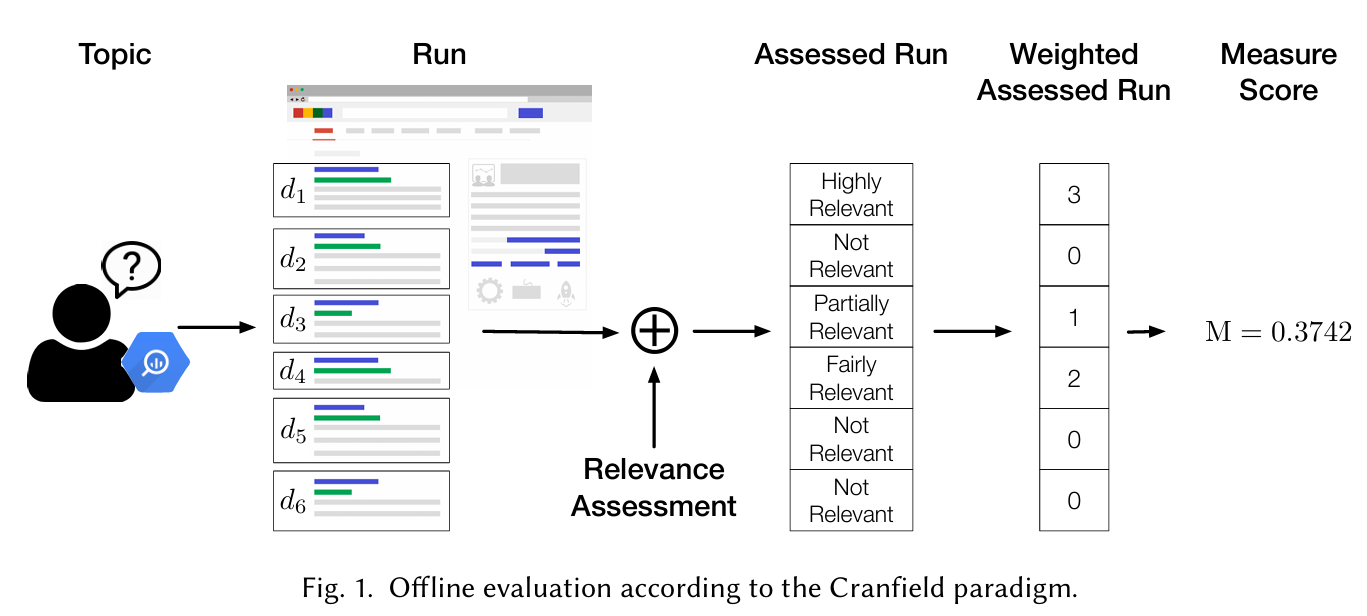

Image source: https://www.dei.unipd.it/~ferro/papers/2024/IR-Book2024-FM.pdf

Cranfield Paradigm merupakan  kerangka kerja evaluasi untuk mengukur efektivitas *search engine* secara objektif tanpa melibatkan pengguna secara langsung pada setiap pengujian. Metodologi ini berfokus pada penggunaan *Test Collection* yang terdiri dari tiga komponen utama: corpus dokumen ($D$), sekumpulan topik ($T$), dan *query relevance* $A$.

- Run: Setiap topik $t \in T$ diproses *search engine* untuk menghasilkan *ranked retrieval* yang disebut sebagai Run.
- Relevance Assestment: menggunakan *query relevance* hasil *Run* dinilai secara biner (relevan/tidak relevan) atau gradasi (Highly relevant - Not relevant) yang kemudian dipetakan sesuai bobot skornya untuk menghasilkan *Weighted Assessed Run*
- Perhitungan Skor: Nilai yang didapatkan digunakan untuk penghitungan metrik seperti Precision@K, Recall@K, atau nDCG@K.

---
Dalam tutorial ini, kita akan berfokus pada pendekatan *offline evaluation*. Dengan menggunakan *test collection* dan metrik evaluasi yang telah dijelaskan sebelumnya, kita akan melihat bagaimana performa berbagai model *sparse retrieval* seperti TF-IDF, BM25, dan *query likelihood model* dapat dibandingkan secara sistematis pada dataset kita.

In [ ]:
# Dalam Information Retrieval, kita memerlukan "Topics" (sekumpulan query)
# dan "Qrels" (Query Relevance(s): penilaian relevansi sebagai ground truth)
topics = dataset.get_topics()
qrels = dataset.get_qrels()

display(topics)
display(qrels)

,qid,query
0,1,what similarity laws must be obeyed when constructing aeroelastic models\nof heated high speed aircraft .
1,2,what are the structural and aeroelastic problems associated with flight\nof high speed aircraft .
2,3,what problems of heat conduction in composite slabs have been solved so\nfar .
3,4,can a criterion be developed to show empirically the validity of flow\nsolutions for chemically reacting gas mixtures based on the simplifying\nassumption of instantaneous local chemical equilibrium .
4,5,what chemical kinetic system is applicable to hypersonic aerodynamic\nproblems .
...,...,...
220,221,papers applicable to this problem (calculation procedures for laminar\nincompressible flow with arbitrary pressure gradient) .
221,222,has anyone investigated the shear buckling of stiffened plates .
222,223,papers on shear buckling of unstiffened rectangular plates under shear .
223,224,"in practice, how close to reality are the assumptions that the flow\nin a hypersonic shock tube using nitrogen is non-viscous and in\nthermodynamic equilibrium ."


,qid,docno,label,iteration
0,1,184,2,0
1,1,29,2,0
2,1,31,2,0
3,1,12,3,0
4,1,51,3,0
...,...,...,...,...
1832,225,1062,3,0
1833,225,1074,3,0
1834,225,1075,3,0
1835,225,1213,3,0


Kali ini, kita akan uji bagaimana performa TF-IDF, BM25, dan QLM pada test collection dataset kita dengan melihat skor Prec@10, Recall@10, dan nDCG@10.

In [ ]:
# pt.Experiment digunakan untuk menjalankan berbagai model retrieval
# terhadap kumpulan query, lalu membandingkan hasilnya dengan qrels
evaluation_results = pt.Experiment(
    #Daftar pipeline atau model retrieval yang akan diuji
    [tfidf_model, bm25_model, qlm_model],

    # Kumpulan query yang akan digunakan dalam evaluasi
    topics,

    # Ground truth berupa penilaian relevansi dokumen
    qrels,

    # Evaluasi: P_10 = Precision@10, recall_10 = Recall@10, ndcg_cut_10 = nDCG@10
    eval_metrics=["ndcg_cut_10", "P_10", "recall_10"],

    names=["TF-IDF", "BM25", "QLM (Dirichlet)"]
)

print("\nHasil Akhir Evaluasi:")
display(evaluation_results)


Hasil Akhir Evaluasi:


,name,P_10,recall_10,ndcg_cut_10
0,TF-IDF,0.233778,0.391660,0.335183
1,BM25,0.235111,0.395086,0.333743
2,QLM (Dirichlet),0.193333,0.342178,0.281813


### Bagaimana Mengetahui Apakah BM25 Secara Signifikan Lebih Baik dari TF-IDF? Dan Jika Ya, Seberapa Besar Improvementnya?

Ketika kita membandingkan dua sistem *information retrieval*, misalnya TF-IDF dan BM25, sering kali kita hanya melihat perbedaan nilai metrik evaluasi seperti *nDCG* atau *Average Precision*. Misalnya, kita menemukan bahwa BM25 memiliki nilai *nDCG@10* sebesar 0.42 sedangkan TF-IDF memiliki nilai 0.39. Secara intuitif kita mungkin langsung menyimpulkan bahwa BM25 lebih baik.

Namun, dalam praktik penelitian *information retrieval*, kesimpulan seperti itu belum tentu cukup kuat. Perbedaan nilai metrik bisa saja terjadi karena variasi data atau karena beberapa *query* tertentu yang kebetulan memberikan keuntungan pada salah satu model. Oleh karena itu, kita perlu memeriksa apakah perbedaan performa tersebut benar-benar signifikan secara statistik.

Di sinilah *statistical significance test* digunakan. Tujuannya adalah untuk memastikan bahwa peningkatan performa yang kita lihat bukan hanya kebetulan, tetapi benar-benar menunjukkan bahwa satu model secara konsisten lebih baik dibandingkan model lainnya.

Salah satu metode yang paling umum digunakan dalam evaluasi *information retrieval* adalah *paired t-test*.

---

#### Paired t-test

Dalam konteks evaluasi *IR*, kita biasanya memiliki banyak *query* dalam sebuah *test collection*. Untuk setiap *query*, kita dapat menghitung nilai metrik evaluasi seperti *AP* atau *nDCG* untuk kedua sistem yang dibandingkan.

Sebagai contoh, misalkan kita memiliki nilai *Average Precision* untuk setiap *query* sebagai berikut:

| Query | TF-IDF | BM25 |
|------|------|------|
| q1 | 0.32 | 0.41 |
| q2 | 0.55 | 0.58 |
| q3 | 0.21 | 0.29 |
| ... | ... | ... |

Alih-alih hanya membandingkan rata-rata keseluruhan, *paired t-test* melihat selisih performa pada setiap query. Dengan kata lain, kita menghitung:

$$
d_i = score_i^{BM25} - score_i^{TFIDF}
$$

Dimana $d_i$ adalah selisih skor pada query ke-$i$.

Jika BM25 memang lebih baik secara konsisten, maka rata-rata nilai selisih ini seharusnya positif.

---

#### Rumus Paired t-test

Setelah kita menghitung selisih untuk setiap query, kita dapat menghitung rata-rata selisih:

$$
\bar{d} = \frac{1}{n} \sum_{i=1}^{n} d_i
$$

Kemudian kita hitung standar deviasi dari selisih tersebut:

$$
s_d = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(d_i - \bar{d})^2}
$$

Statistik *t* kemudian dihitung sebagai:

$$
t = \frac{\bar{d} - \mu_d}{s_d / \sqrt{n}}
$$

Dimana:
- $n$ adalah jumlah *query*
- $\bar{d}$ adalah rata-rata selisih skor
- $s_d$ adalah standar deviasi selisih skor
- $\mu_d$ adalah theoreical populaion mean difference

Nilai *t* ini kemudian digunakan untuk menghitung p-value, yaitu probabilitas bahwa perbedaan yang kita lihat sebenarnya hanya terjadi karena kebetulan.

---

#### Interpretasi p-value

Dalam banyak penelitian, ambang yang sering digunakan adalah:

$$
p < 0.05
$$

Jika nilai *p-value* lebih kecil dari 0.05, maka perbedaan performa dianggap signifikan secara statistik. Artinya, kita dapat lebih yakin bahwa peningkatan performa BM25 dibanding TF-IDF bukan sekadar kebetulan.

Sebaliknya, jika nilai *p-value* lebih besar dari 0.05, maka kita tidak memiliki cukup bukti untuk menyatakan bahwa satu sistem benar-benar lebih baik dari yang lain.


Penggunaan *statistical significance test* sangat penting dalam penelitian *information retrieval*. Tanpa uji statistik, kita berisiko membuat klaim yang terlalu kuat hanya berdasarkan perbedaan kecil pada nilai rata-rata metrik evaluasi.

Dengan menggunakan *paired t-test*, kita dapat mengevaluasi apakah peningkatan performa suatu model benar-benar konsisten di banyak *query*, bukan hanya disebabkan oleh beberapa kasus tertentu.


Pada bagian selanjutnya, kita akan menerapkan pendekatan ini untuk membandingkan performa beberapa metode *sparse retrieval*. Setelah menghitung metrik evaluasi untuk setiap *query*, kita akan menggunakan *paired t-test* untuk melihat apakah perbedaan performa antar metode tersebut signifikan secara statistik.

Kita akan membuktikan secara statistik model mana antara BM25 dengan QLM yang lebih baik dari TF-IDF jika dilihat dari metrik-metrik seperti precision, recall, dan nDCG.

In [ ]:
metrics = ["ndcg_cut_10", "P_10", "recall_10"]
query_results = pt.Experiment(
    [tfidf_model, bm25_model, qlm_model],
    topics,
    qrels,
    eval_metrics=metrics,
    names=["TF-IDF", "BM25", "QLM (Dirichlet)"],
    perquery=True #  True untuk analisis per query (dibutuhkan untuk paired t-test)
)

df_tfidf = query_results[query_results["name"] == "TF-IDF"].sort_values("qid")
df_bm25  = query_results[query_results["name"] == "BM25"].sort_values("qid")
df_qlm   = query_results[query_results["name"] == "QLM (Dirichlet)"].sort_values("qid")

In [ ]:
df_tfidf.head()

,name,qid,measure,value
0,TF-IDF,1,P_10,0.300000
1,TF-IDF,1,recall_10,0.107143
2,TF-IDF,1,ndcg_cut_10,0.305391
27,TF-IDF,10,P_10,0.100000
28,TF-IDF,10,recall_10,0.125000


In [ ]:

import numpy as np
from scipy.stats import ttest_rel

comb_eval = []
for metric in metrics:
    score_tfidf = df_tfidf[df_tfidf["measure"] == metric].sort_values("qid")["value"].values
    score_bm25  = df_bm25[df_bm25["measure"] == metric].sort_values("qid")["value"].values
    score_qlm   = df_qlm[df_qlm["measure"] == metric].sort_values("qid")["value"].values

    if len(score_tfidf) == 0 or len(score_tfidf) != len(score_bm25):
        print(f"Melewati {metric} karena jumlah data tidak sama atau kosong.")
        continue

    # Hitung Glass's Delta
    mean_baseline = np.mean(score_tfidf)
    sd_baseline   = np.std(score_tfidf, ddof=1)

    if sd_baseline != 0:
        glass_bm25 = (np.mean(score_bm25) - mean_baseline) / sd_baseline
        glass_qlm  = (np.mean(score_qlm) - mean_baseline) / sd_baseline
    else:
        glass_bm25 = np.nan
        glass_qlm  = np.nan

    t_stat_bm25, p_val_bm25 = ttest_rel(score_tfidf, score_bm25)
    t_stat_qlm, p_val_qlm   = ttest_rel(score_tfidf, score_qlm)

    comb_eval.append({
        "Metric": metric,
        "Glass' Δ (BM25)": glass_bm25,
        "P-Value (BM25)": p_val_bm25,
        "Glass' Δ (QLM)": glass_qlm,
        "P-Value (QLM)": p_val_qlm
    })

df_evaluasi = pd.DataFrame(comb_eval)
print("\nHasil Uji T-Test & Effect Size (Glass' Delta)")
print("Baseline: TF-IDF")
display(df_evaluasi)


Hasil Uji T-Test & Effect Size (Glass' Delta)
Baseline: TF-IDF


,Metric,Glass' Δ (BM25),P-Value (BM25),Glass' Δ (QLM),P-Value (QLM)
0,ndcg_cut_10,-0.005646,0.630875,-0.209327,1.753943e-08
1,P_10,0.007354,0.613176,-0.223073,1.366132e-07
2,recall_10,0.011456,0.299584,-0.165452,5.196385e-06


#### Analisis Hasil Uji Statistik

Tabel di atas menampilkan hasil perbandingan performa beberapa model *sparse retrieval* dengan menggunakan dua jenis analisis, yaitu *statistical significance test* melalui *paired t-test* dan pengukuran *effect size* menggunakan *Glass's Delta*. Dalam eksperimen ini, TF-IDF digunakan sebagai *baseline*, sehingga performa BM25 dan QLM dibandingkan langsung terhadap TF-IDF. Evaluasi dilakukan pada tiga metrik *information retrieval*, yaitu *nDCG@10*, *Precision@10*, dan *Recall@10*. Nilai metrik tersebut dihitung untuk setiap *query*, kemudian digunakan sebagai pasangan observasi dalam uji statistik.

Kolom *P-Value* pada tabel berasal dari hasil *paired t-test* antara skor per-query TF-IDF dengan model yang dibandingkan. Uji ini digunakan untuk melihat apakah perbedaan performa yang muncul benar-benar signifikan secara statistik atau hanya terjadi karena variasi data. Secara umum, jika nilai *p-value* lebih kecil dari 0.05 maka perbedaan performa dianggap signifikan. Sebaliknya, jika *p-value* lebih besar dari 0.05 maka kita tidak memiliki cukup bukti untuk menyatakan bahwa satu model benar-benar lebih baik dari model lainnya.

Selain uji signifikansi, kita juga menghitung nilai [*Glass's Delta*](https://www.statisticshowto.com/glasss-delta/). Nilai ini merupakan ukuran *effect size*, yaitu ukuran yang menunjukkan seberapa besar dampak atau perbedaan performa antara dua model. Berbeda dengan *p-value* yang hanya menunjukkan apakah perbedaannya signifikan atau tidak, *effect size* membantu kita memahami seberapa besar peningkatan atau penurunan performa tersebut. *Glass's Delta* dihitung dengan membandingkan selisih rata-rata skor model terhadap rata-rata baseline, kemudian dinormalisasi dengan standar deviasi baseline.

Secara matematis, *Glass's Delta* dapat dituliskan sebagai:

$$
\Delta = \frac{\mu_{model} - \mu_{baseline}}{\sigma_{baseline}}
$$

Dimana $\mu_{model}$ adalah rata-rata skor model yang dibandingkan, $\mu_{baseline}$ adalah rata-rata skor TF-IDF sebagai baseline, dan $\sigma_{baseline}$ adalah standar deviasi skor TF-IDF. Nilai positif menunjukkan bahwa model memiliki performa lebih baik dibanding baseline, sedangkan nilai negatif menunjukkan performa yang lebih rendah. Besarnya nilai tersebut juga dapat memberikan gambaran apakah efeknya kecil, sedang, atau besar.

Berdasarkan tabel hasil evaluasi, BM25 menunjukkan nilai *Glass's Delta* yang sangat kecil pada ketiga metrik evaluasi, dan seluruh nilai *p-value* berada di atas 0.05. Hal ini menunjukkan bahwa performa BM25 pada dataset ini tidak berbeda secara signifikan dibandingkan TF-IDF. Dengan kata lain, meskipun secara teori BM25 sering dianggap sebagai peningkatan dari TF-IDF, pada koleksi dokumen ini kita tidak menemukan bukti statistik yang cukup kuat bahwa BM25 benar-benar memberikan peningkatan performa.

Sementara itu, model QLM menunjukkan nilai *Glass's Delta* yang bernilai negatif pada ketiga metrik evaluasi, dengan *p-value* yang sangat kecil. Hal ini mengindikasikan bahwa performa QLM secara konsisten lebih rendah dibandingkan TF-IDF, dan perbedaan tersebut signifikan secara statistik. Dengan demikian, pada eksperimen ini QLM cenderung menghasilkan kualitas retrieval yang lebih buruk dibandingkan baseline.